# Accessing ARGO data

Initially working from the summary sheet: https://argopy.readthedocs.io/en/latest/_static/argopy-cheatsheet.pdf


In [30]:
# Download a dataset based on longitude, latitude, pressure and time range
from argopy import DataFetcher
fetcher = DataFetcher().region([-75, -45, 20, 30, 0, 100, '2026-02', '2026-04'])

In [3]:
# Alternatively download specific float profiles
fetcher1 = DataFetcher().float([6902746, 6902755])

In [4]:
# Or specific cycles of a given float
fetcher2 = DataFetcher().profile(6902746, [1,12])

In [5]:
# convert to xarray
fetcher.to_xarray()
# gives an error, but can probably be ignored for now since the dataframe and dataset methods work fine

<xarray.Dataset> Size: 1MB
Dimensions:          (N_POINTS: 9422)
Coordinates:
    LATITUDE         (N_POINTS) float64 75kB 24.54 24.54 24.54 ... 24.96 24.96
    LONGITUDE        (N_POINTS) float64 75kB -45.14 -45.14 ... -50.4 -50.4
    TIME             (N_POINTS) datetime64[ns] 75kB 2011-01-01T11:49:19 ... 2...
  * N_POINTS         (N_POINTS) int64 75kB 0 1 2 3 4 ... 9418 9419 9420 9421
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 75kB 23 23 23 23 23 23 ... 38 38 38 38 38
    DATA_MODE        (N_POINTS) <U1 38kB 'D' 'D' 'D' 'D' 'D' ... 'D' 'D' 'D' 'D'
    DIRECTION        (N_POINTS) <U1 38kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 75kB 1901463 1901463 ... 1901463 1901463
    POSITION_QC      (N_POINTS) int64 75kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 38kB 5.0 10.0 15.0 ... 90.0 95.0 100.0
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 38kB 0.01 0.01 0.01 ... 0.01017 0.01016
    PSAL_QC          (N_POINTS) int64 75kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 38kB 24.08 24.08 24.09 ... 21.28 21.19
    TEMP_ERROR       (N_POINTS) float32 38kB 0.002 0.002 0.002 ... 0.002 0.002
    TEMP_QC          (N_POINTS) int64 75kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 75kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           ifenton
    Fetched_date:         2026/03/04
    Fetched_constraints:  [x=-75.00/-45.00; y=20.00/30.00; z=0.0/100.0; t=201...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [31]:
# convert to pandas dataframe
fetcher.to_dataframe()

,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME
N_POINTS,,,,,,,,,,,,,,,,,,
0,152,R,A,1902316,1,1.000000,NaN,1,37.178001,NaN,1,24.617001,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
1,152,R,A,1902316,1,2.000000,NaN,1,37.175999,NaN,1,24.618000,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
2,152,R,A,1902316,1,2.960000,NaN,1,37.178001,NaN,1,24.620001,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
3,152,R,A,1902316,1,3.960000,NaN,1,37.178001,NaN,1,24.624001,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
4,152,R,A,1902316,1,4.960000,NaN,1,37.178001,NaN,1,24.622000,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8223,239,R,A,4903225,1,91.959999,NaN,1,37.570999,NaN,1,25.122000,NaN,1,1,20.11915,-47.35972,2026-03-03 13:54:43
8224,239,R,A,4903225,1,93.959999,NaN,1,37.570000,NaN,1,25.083000,NaN,1,1,20.11915,-47.35972,2026-03-03 13:54:43
8225,239,R,A,4903225,1,95.959999,NaN,1,37.568001,NaN,1,25.063000,NaN,1,1,20.11915,-47.35972,2026-03-03 13:54:43


In [7]:
# convert to netcdf dataset (n.b. don't need to go via other formats)
fetcher.to_dataset()

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    DATA_ID: ARGO
    DOI: http://doi.org/10.17882/42182
    Fetched_from: erddap.ifremer.fr
    Fetched_by: ifenton
    Fetched_date: 2026/03/04
    Fetched_constraints: [x=-75.00/-45.00; y=20.00/30.00; z=0.0/100.0; t=2011-01-01/2011-06-01]
    Fetched_uri: https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats.nc?config_mission_number,cycle_number,data_mode,direction,latitude,longitude,platform_number,position_qc,pres,pres_adjusted,pres_adjusted_error,pres_adjusted_qc,pres_qc,psal,psal_adjusted,psal_adjusted_error,psal_adjusted_qc,psal_qc,temp,temp_adjusted,temp_adjusted_error,temp_adjusted_qc,temp_qc,time,time_qc,vertical_sampling_scheme&longitude%3E=-75&longitude%3C=-45&latitude%3E=20&latitude%3C=30&pres%3E=0&pres%3C=100&time%3E=1293840000.0&time%3C=1306886400.0&latitude!=NaN&longitude!=NaN&distinct()&orderBy(%22time,pres%22)
    Processing_history: [PRES,TEMP,PSAL] real-time and adjusted/delayed variables m

In [8]:
# look at the data
fetcher.data

<xarray.Dataset> Size: 1MB
Dimensions:          (N_POINTS: 9422)
Coordinates:
    LATITUDE         (N_POINTS) float64 75kB 24.54 24.54 24.54 ... 24.96 24.96
    LONGITUDE        (N_POINTS) float64 75kB -45.14 -45.14 ... -50.4 -50.4
    TIME             (N_POINTS) datetime64[ns] 75kB 2011-01-01T11:49:19 ... 2...
  * N_POINTS         (N_POINTS) int64 75kB 0 1 2 3 4 ... 9418 9419 9420 9421
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 75kB 23 23 23 23 23 23 ... 38 38 38 38 38
    DATA_MODE        (N_POINTS) <U1 38kB 'D' 'D' 'D' 'D' 'D' ... 'D' 'D' 'D' 'D'
    DIRECTION        (N_POINTS) <U1 38kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 75kB 1901463 1901463 ... 1901463 1901463
    POSITION_QC      (N_POINTS) int64 75kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 38kB 5.0 10.0 15.0 ... 90.0 95.0 100.0
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 38kB 0.01 0.01 0.01 ... 0.01017 0.01016
    PSAL_QC          (N_POINTS) int64 75kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 38kB 24.08 24.08 24.09 ... 21.28 21.19
    TEMP_ERROR       (N_POINTS) float32 38kB 0.002 0.002 0.002 ... 0.002 0.002
    TEMP_QC          (N_POINTS) int64 75kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 75kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           ifenton
    Fetched_date:         2026/03/04
    Fetched_constraints:  [x=-75.00/-45.00; y=20.00/30.00; z=0.0/100.0; t=201...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [9]:
# data index
fetcher.index

,date,latitude,longitude,wmo,cyc
0,2011-01-02 11:26:40,27.829,-56.303,1901461,23
1,2011-01-12 11:44:20,27.988,-56.378,1901461,24
2,2011-01-22 11:23:26,27.891,-55.865,1901461,25
3,2011-02-01 11:18:38,27.538,-54.669,1901461,26
4,2011-02-11 11:46:04,27.487,-53.686,1901461,27
...,...,...,...,...,...
464,2011-05-12 01:25:11,27.498,-70.044,6901050,3
465,2011-05-22 05:10:25,26.491,-70.192,6901050,4
466,2011-05-20 16:30:09,21.120,-57.985,6901051,1
467,2011-05-30 16:18:21,21.489,-58.071,6901051,2


# Setting the user mode

Defaults to `standard`, but can also choose `research` or `expert`

Select with global option setter:
`argopy.set_options(mode='expert')`
Select in a temporary context:
```
with argopy.set_options(mode='expert'):
    DataFetcher().profile(6902746, 34)
```
Select with fetcher options:
`DataFetcher(mode='research').region([-75, -45, 20, 30, 0, 100])`


# Plotting

(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='longitude', ylabel='latitude'>)

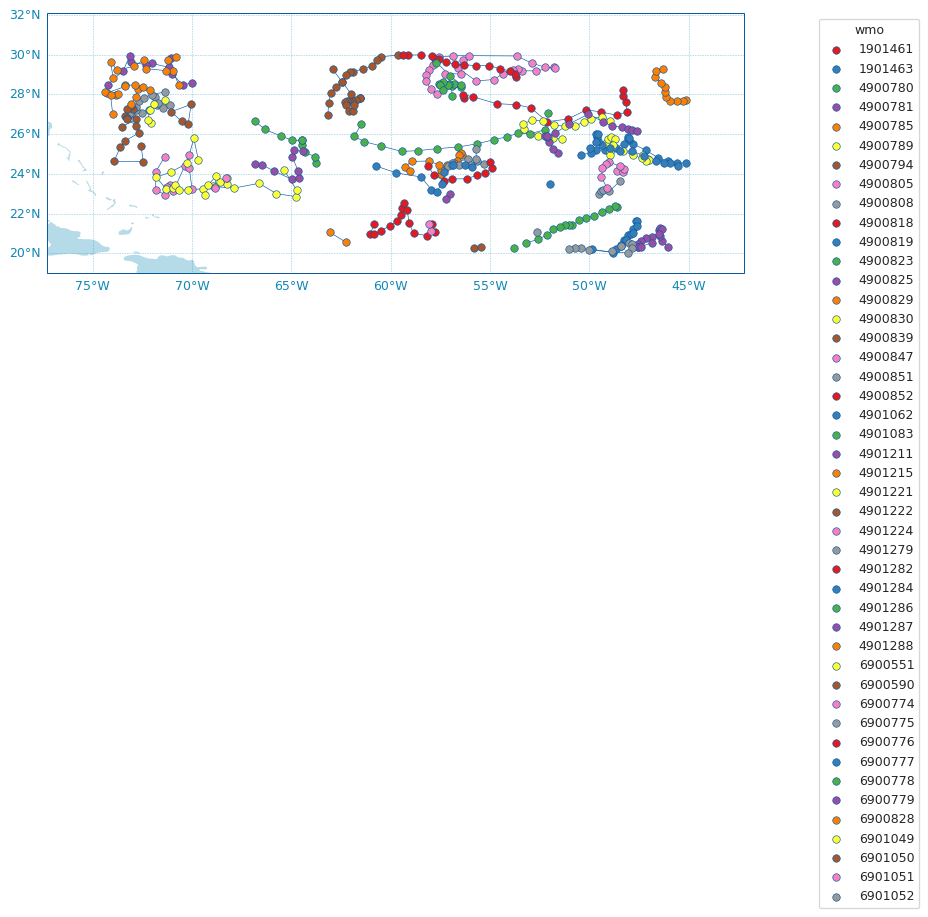

In [10]:
fetcher.plot()

(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='longitude', ylabel='latitude'>)

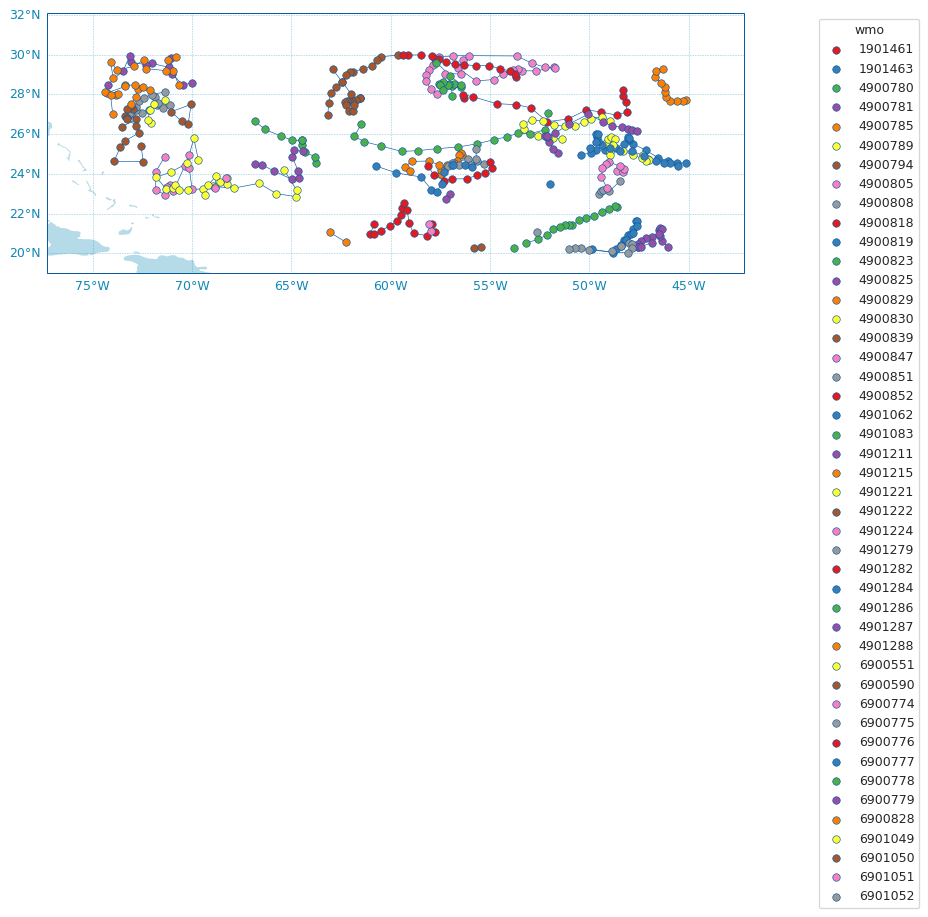

In [11]:
fetcher.plot('trajectory')


(<Figure size 900x540 with 1 Axes>, <Axes: xlabel='Number of profiles'>)

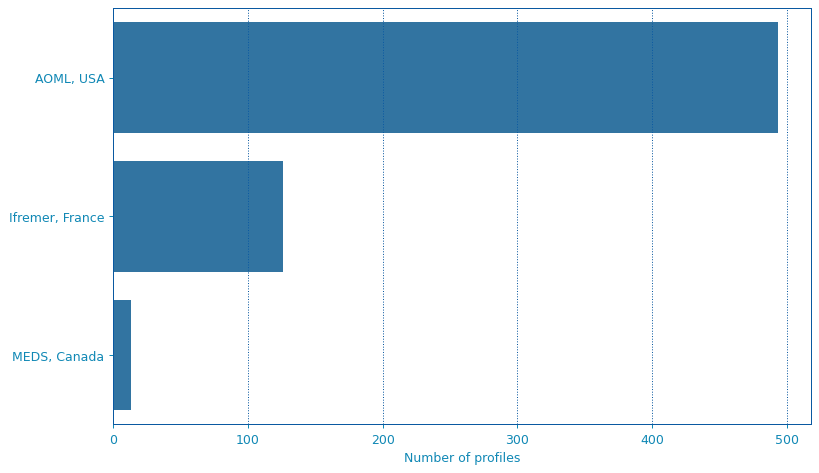

In [12]:
fetcher.plot('dac')


(<Figure size 900x540 with 1 Axes>, <Axes: xlabel='Number of profiles'>)

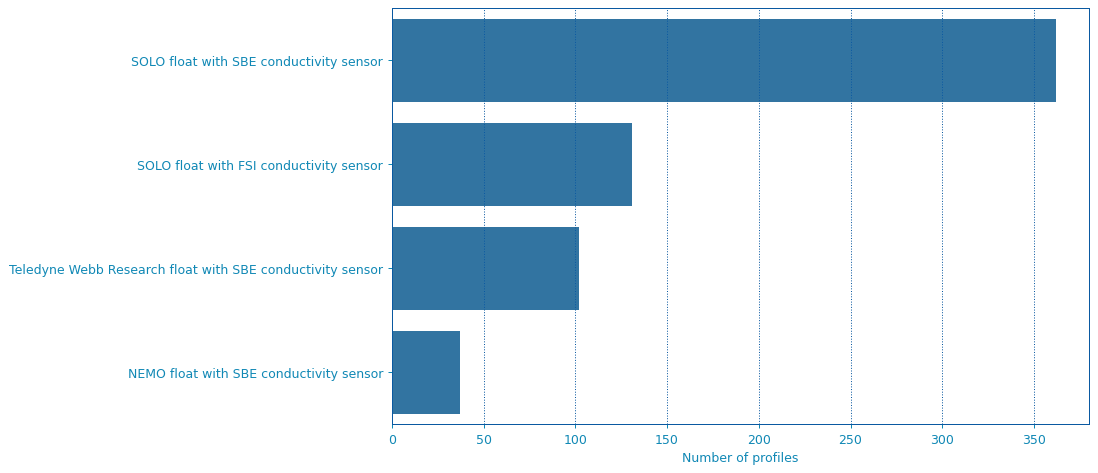

In [13]:
fetcher.plot('profiler')


(<Figure size 900x540 with 2 Axes>,
 <GeoAxes: title={'center': 'Argo float WMO: 6902746'}, xlabel='Longitude of the station, best\nestimate [degree_east]', ylabel='Latitude of the station, best\nestimate [degree_north]'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x3066001d0>,
  'cbar': <matplotlib.colorbar.Colorbar at 0x30661fb90>,
  'legend': None,
  'traj': [<matplotlib.lines.Line2D at 0x306b14690>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x306cddc90>})

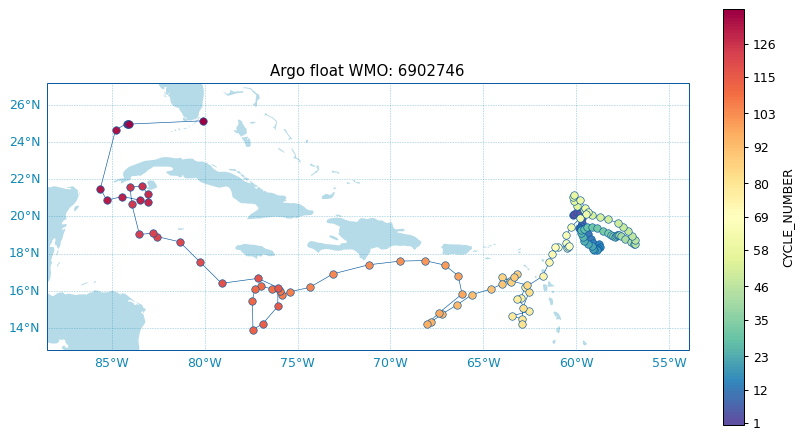

In [14]:
# ArgoFloat
from argopy import ArgoFloat
af = ArgoFloat(6902746)
af.plot.trajectory()


/Users/ifenton/Documents/Projects/SeaIce/icenet-mp/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2650: RuntimeWarning: invalid value encountered in cast
  output[index] = result


(<Figure size 900x540 with 2 Axes>,
 <GeoAxes: title={'center': 'Argo float WMO: 6902746'}, xlabel='Longitude of the station, best\nestimate [degree_east]', ylabel='Latitude of the station, best\nestimate [degree_north]'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x308643190>,
  'cbar': <matplotlib.colorbar.Colorbar at 0x306bb1d50>,
  'legend': None,
  'traj': [<matplotlib.lines.Line2D at 0x308e45990>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x306dd53d0>})

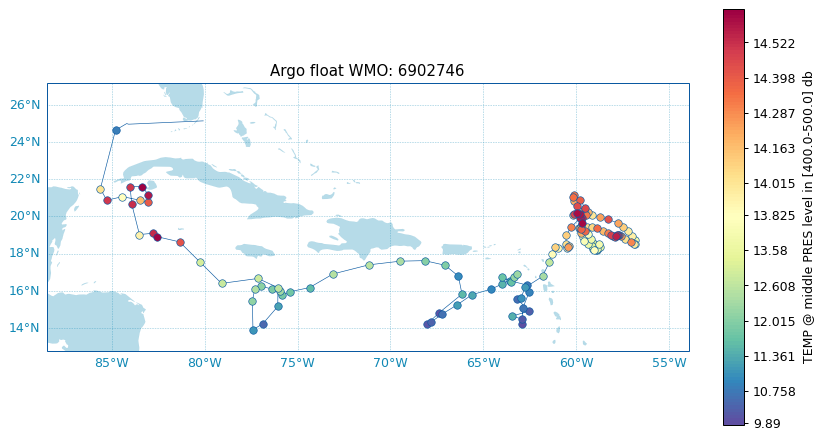

In [15]:
af.plot.map('TEMP', pres=450)


(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='Longitude of the station, best\nestimate', ylabel='Latitude of the station, best\nestimate'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x30921b190>,
  'cbar': None,
  'legend': <matplotlib.legend.Legend at 0x3068e1110>,
  'traj': [<matplotlib.lines.Line2D at 0x30951f590>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x308cb5490>})

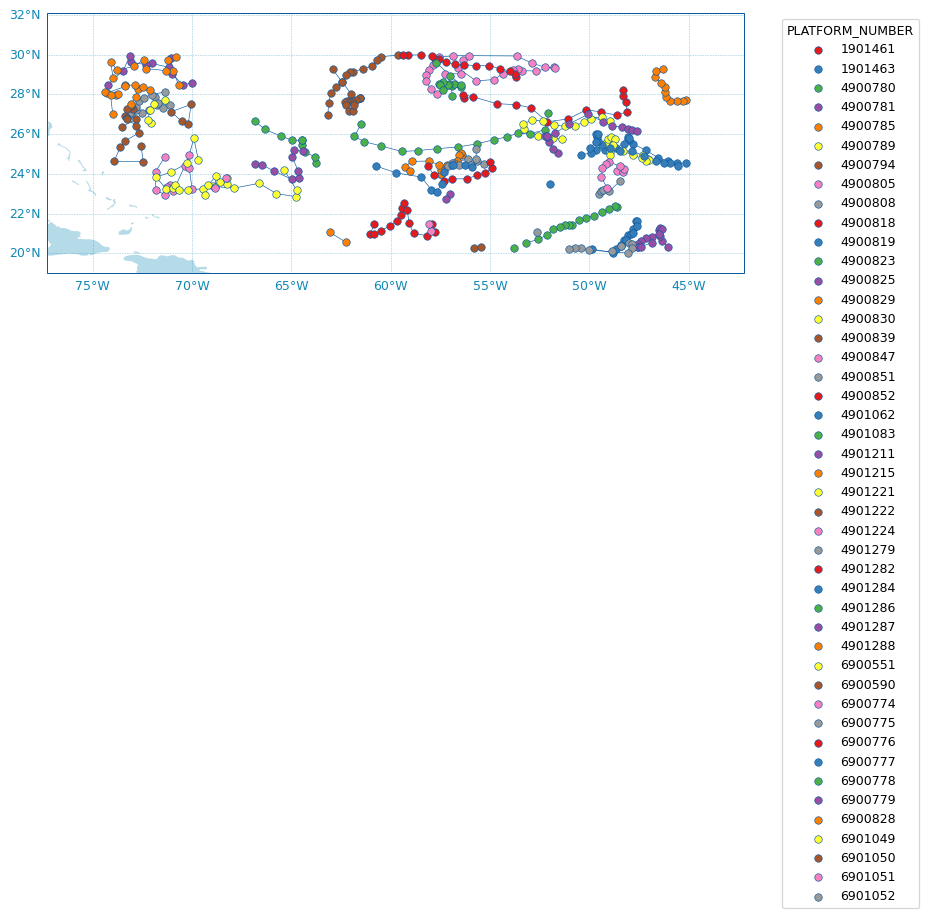

In [16]:
from argopy.plot import scatter_map
ds = fetcher.data.argo.point2profile()
scatter_map(ds)


(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='Longitude of the station, best\nestimate', ylabel='Latitude of the station, best\nestimate'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x308e45710>],
  'cbar': None,
  'legend': <matplotlib.legend.Legend at 0x3092bfbd0>,
  'traj': [<matplotlib.lines.Line2D at 0x309697fd0>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x30660ea50>})

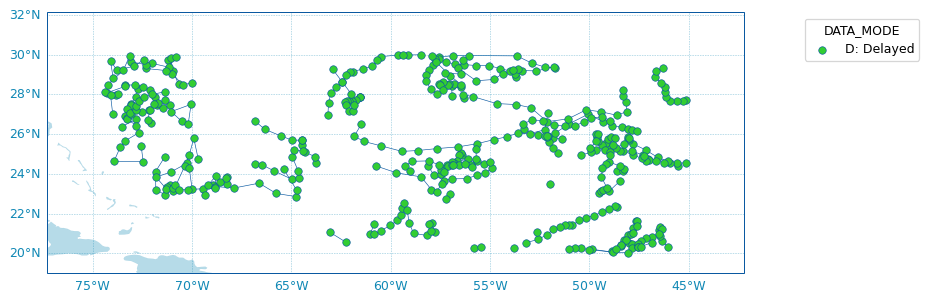

In [17]:
scatter_map(ds, hue='DATA_MODE')


(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='Longitude of the station, best\nestimate', ylabel='Latitude of the station, best\nestimate'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x3096c3050>,
  'cbar': None,
  'legend': <matplotlib.legend.Legend at 0x309839e10>,
  'traj': [<matplotlib.lines.Line2D at 0x30985b250>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x308de8d90>})

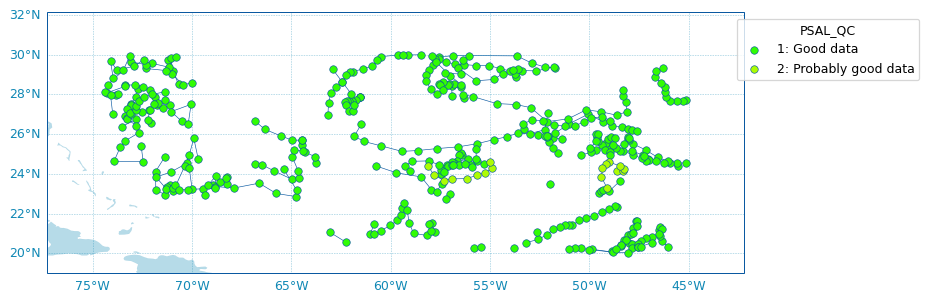

In [18]:
scatter_map(ds.isel(N_LEVELS=0), hue='PSAL_QC')


(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='Longitude of the station, best\nestimate', ylabel='Latitude of the station, best\nestimate'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x3098d54d0>],
  'cbar': None,
  'legend': <matplotlib.legend.Legend at 0x309909250>,
  'traj': [<matplotlib.lines.Line2D at 0x309930ad0>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x30981a650>})

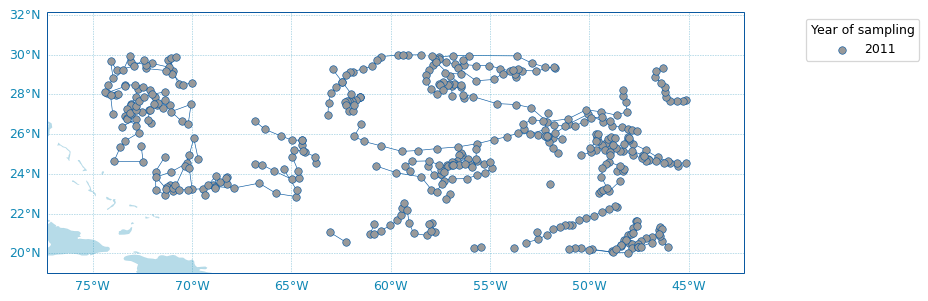

In [19]:
ds['year'] = ds['TIME.year'] # Add a variable
scatter_map(ds.isel(N_LEVELS=0),
hue='year',
legend_title='Year of sampling')

# Potentially useful data

In [20]:
test_data = DataFetcher().region([-180, 180, 70, 90, 0, 5, '2011-01', '2011-06'])
test_data.to_dataframe()

,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME
N_POINTS,,,,,,,,,,,,,,,,,,
0,62,D,A,6901387,1,4.30,2.4,1,35.066002,0.01,1,2.839,0.002,1,1,79.0439,4.71669,2011-01-01 11:54:33
1,63,D,A,6901387,1,2.60,2.4,1,35.053001,0.01,1,2.764,0.002,1,1,79.1290,4.18030,2011-01-04 11:57:07
2,63,D,A,6901387,1,4.80,2.4,1,35.053001,0.01,1,2.764,0.002,1,1,79.1290,4.18030,2011-01-04 11:57:07
3,7,D,A,6900799,1,3.36,2.4,1,35.221699,0.01,1,6.009,0.002,1,1,70.4540,5.17500,2011-01-04 23:41:17
4,7,D,A,6900799,1,4.56,2.4,1,35.221722,0.01,1,6.008,0.002,1,1,70.4540,5.17500,2011-01-04 23:41:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,206,D,A,6900345,1,4.80,2.4,1,35.048000,0.01,1,2.457,0.002,1,1,76.9740,5.92800,2011-05-28 07:08:13
78,33,D,A,6900810,1,2.40,2.4,1,34.840000,0.01,1,7.244,0.002,1,1,70.0180,14.83700,2011-05-28 09:19:06
79,111,D,A,6901387,1,0.50,2.4,1,34.745998,0.01,1,0.910,0.002,1,1,74.9212,-4.13467,2011-05-28 12:38:17


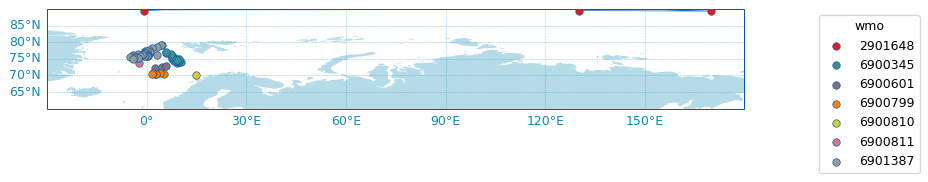

In [26]:
import matplotlib.pyplot as plt

# Create a figure and axes with specific limits
scatter_map(test_data.index)
plt.xlim(-30, 180)  # longitude limits
plt.ylim(60, 90)   # latitude limits
plt.show()

In [27]:
test_data_SH = DataFetcher().region([-180, 180, -90, -70, 0, 5, '2026-01', '2026-03'])
test_data_SH.to_dataframe()

,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME
N_POINTS,,,,,,,,,,,,,,,,,,
0,41,R,A,5907097,1,3.0,NaN,1,34.153000,NaN,1,-1.590,NaN,1,1,-75.188488,-29.992770,2026-01-01 01:44:00
1,41,R,A,5907097,1,4.0,NaN,1,34.153999,NaN,1,-1.601,NaN,1,1,-75.188488,-29.992770,2026-01-01 01:44:00
2,41,R,A,5907097,1,5.0,NaN,1,34.153999,NaN,1,-1.606,NaN,1,1,-75.188488,-29.992770,2026-01-01 01:44:00
3,46,R,A,1902769,1,3.8,NaN,1,34.389000,NaN,1,0.190,NaN,1,1,-77.374667,176.205290,2026-01-01 05:37:00
4,165,R,A,6903832,1,3.4,NaN,1,34.292000,NaN,1,0.114,NaN,1,1,-77.077137,173.023917,2026-01-01 05:50:20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,56,R,A,6990712,1,3.9,NaN,1,34.231998,NaN,1,-1.596,NaN,1,1,-77.318330,174.224105,2026-02-28 05:13:20
451,224,A,A,6903770,1,3.5,NaN,1,33.592999,NaN,1,-1.300,NaN,1,1,-72.325427,-154.322785,2026-02-28 09:20:30
452,47,R,A,5907097,1,3.0,NaN,1,33.907001,NaN,1,-1.220,NaN,1,1,-75.230602,-30.163117,2026-02-28 19:42:00


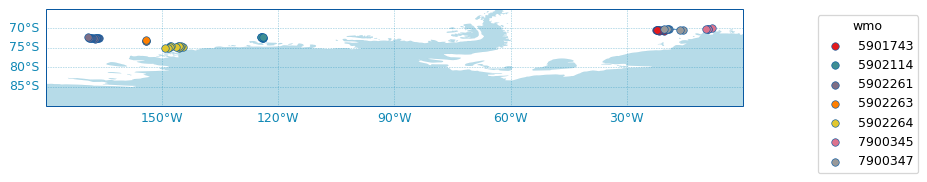

In [23]:
scatter_map(test_data_SH.index)
plt.xlim(-180, 0)  # longitude limits
plt.ylim(-90, -65)   # latitude limits
plt.show()

In [24]:
test_data.to_xarray().argo.to_zarr("../../zebra_anemoi/test_sample.zarr")

ContainsGroupError: path '' contains a group